# Data Quality Investigation
This notebook explores the Sri Lanka A/L UGC Cutoff data to ensure strict data quality, validate referential integrity, and understand missing data distribution (e.g., NQC cells).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set working directory to project root if running inside notebooks/
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print(f'Current Working Directory: {os.getcwd()}')

Current Working Directory: c:\Users\Dilhara Jayawardhana\Projects\Dev\DS-Projects\al-trends


In [2]:
# Load Data
fact_df = pd.read_csv('data/bronze/csv/fact_cutoffs.csv')
course_dim = pd.read_csv('data/bronze/csv/dim_course.csv')
uni_dim = pd.read_csv('data/bronze/csv/dim_university.csv')

print(f'Fact rows: {len(fact_df):,}')

Fact rows: 50,025


## 1. Missing Value & Cutoff Status Analysis
Let's investigate the `CutoffStatus` column and how many `CutoffZ` values are legitimately missing due to NQC (Not Qualified for Course) or blank cells in the PDF.

In [3]:
# Cutoff Status Distribution
status_counts = fact_df['CutoffStatus'].value_counts(dropna=False)
print('Cutoff Status Distribution:')
print(status_counts)

# Calculate percentage of legitimately missing Z-scores
missing_z = fact_df['CutoffZ'].isnull().sum()
total_rows = len(fact_df)
print(f'\nMissing CutoffZ: {missing_z:,} ({(missing_z/total_rows)*100:.2f}%)')

Cutoff Status Distribution:
CutoffStatus
AVAILABLE    41095
NQC           8930
Name: count, dtype: int64

Missing CutoffZ: 8,930 (17.85%)


## 2. Z-Score Distribution & Outliers
Z-scores typically range between -3.0 and +3.0. Let's check for extreme outliers.

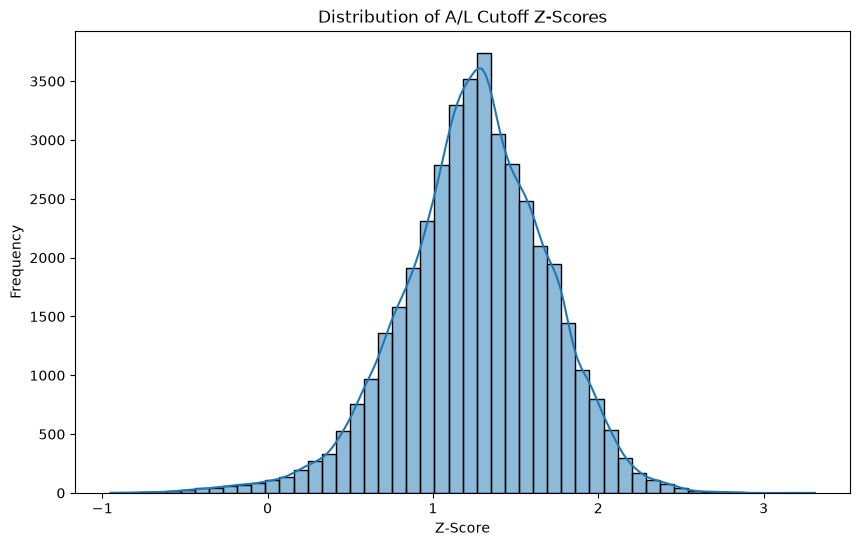

Extreme Outliers (Z > 3.5 or Z < -3.5): 0


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(fact_df['CutoffZ'].dropna(), bins=50, kde=True)
plt.title('Distribution of A/L Cutoff Z-Scores')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

# Detect extreme outliers
outliers = fact_df[(fact_df['CutoffZ'] > 3.5) | (fact_df['CutoffZ'] < -3.5)]
print(f'Extreme Outliers (Z > 3.5 or Z < -3.5): {len(outliers)}')
if not outliers.empty:
    display(outliers.head())

## 3. Referential Integrity Check
Ensure all CourseIDs and UniversityIDs in the fact table exist in the dimension tables.

In [5]:
# Check Courses
missing_courses = set(fact_df['CourseID']) - set(course_dim['CourseID'])
print(f'Missing Course References: {len(missing_courses)}')

# Check Universities
missing_unis = set(fact_df['UniversityID']) - set(uni_dim['UniversityID'])
print(f'Missing University References: {len(missing_unis)}')


Missing Course References: 0
Missing University References: 0
